# Spectrogram-Based CNN for Spoken Digit Recognition

This project uses convolutional neural networks (CNNs) and spectrogram-based feature extraction to classify spoken digits (0–9) from audio recordings.

## 1. Imports

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.signal as signal
import tensorflow as tf
from scipy.io import wavfile
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras.models import Sequential

## Data Loading and Preparation

This section loads audio files, converts them into a structured format, and prepares them for processing.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path

folder_path = Path("/content/drive/MyDrive/recordings")

print(folder_path)
print(f"Exists: {folder_path.exists()}")

/content/drive/MyDrive/recordings
Exists: True


In [4]:
wav_files = list(folder_path.glob("*.wav"))

print(f"Found {len(wav_files)} files")
print(wav_files[:5])

Found 3000 files
[PosixPath('/content/drive/MyDrive/recordings/6_nicolas_29.wav'), PosixPath('/content/drive/MyDrive/recordings/6_theo_37.wav'), PosixPath('/content/drive/MyDrive/recordings/6_theo_7.wav'), PosixPath('/content/drive/MyDrive/recordings/6_nicolas_14.wav'), PosixPath('/content/drive/MyDrive/recordings/6_nicolas_38.wav')]


In [5]:
wav_files = [f for f in os.listdir(folder_path) if f.endswith(".wav")]

print(f"Found {len(wav_files)} WAV files")
print(wav_files[:5])

Found 3000 WAV files
['6_nicolas_29.wav', '6_theo_37.wav', '6_theo_7.wav', '6_nicolas_14.wav', '6_nicolas_38.wav']


In [6]:
audio_data_list = []

for filename in wav_files:
    file_path = folder_path / filename
    try:
        sampling_rate, audio_samples = wavfile.read(file_path)
        audio_data_list.append(
            {
                "filename": filename,
                "sampling_rate": sampling_rate,
                "audio_samples": audio_samples.tolist(),
            }
        )
    except Exception as e:
        print(f"Error processing {filename}: {e}")

print(f"Processed {len(audio_data_list)} out of {len(wav_files)} WAV files.")

if audio_data_list:
    first_entry = audio_data_list[0]
    print(
        f"First entry: {first_entry['filename']}, "
        f"Sampling Rate: {first_entry['sampling_rate']} Hz, "
        f"Audio Samples Length: {len(first_entry['audio_samples'])}"
    )

Processed 3000 out of 3000 WAV files.
First entry: 6_nicolas_29.wav, Sampling Rate: 8000 Hz, Audio Samples Length: 1569


In [7]:
output_json_path = "audio_data.json"

with open(output_json_path, "w") as f:
    json.dump(audio_data_list, f, indent=4)

print(f"Audio data successfully written to {output_json_path}")

Audio data successfully written to audio_data.json


In [8]:
with open("audio_data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

audio_df = pd.DataFrame.from_dict(data)
audio_df.head()

,filename,sampling_rate,audio_samples
0,6_nicolas_29.wav,8000,"[-256, 0, -256, 0, -512, 0, -256, -256, -256, ..."
1,6_theo_37.wav,8000,"[40, -18, 29, -12, 28, -36, -3, 13, -6, -20, -..."
2,6_theo_7.wav,8000,"[-1, -22, -16, 21, 1, 43, 17, -7, 18, 14, 10, ..."
3,6_nicolas_14.wav,8000,"[-256, 256, -256, 0, -256, -256, -256, -256, 2..."
4,6_nicolas_38.wav,8000,"[-256, 0, -256, 0, -256, 0, 0, 0, -512, 0, -25..."


In [9]:
print(f"Data type of 'audio_samples' column: {audio_df['audio_samples'].dtype}")
print(audio_df["audio_samples"].head())

audio_df["audio_samples"] = audio_df["audio_samples"].apply(lambda x: np.array(x))

type(audio_df["audio_samples"].iloc[0])

Data type of 'audio_samples' column: object
0    [-256, 0, -256, 0, -512, 0, -256, -256, -256, ...
1    [40, -18, 29, -12, 28, -36, -3, 13, -6, -20, -...
2    [-1, -22, -16, 21, 1, 43, 17, -7, 18, 14, 10, ...
3    [-256, 256, -256, 0, -256, -256, -256, -256, 2...
4    [-256, 0, -256, 0, -256, 0, 0, 0, -512, 0, -25...
Name: audio_samples, dtype: object


numpy.ndarray

## Feature Engineering: Spectrogram Generation

Audio signals are converted into spectrograms, which provide a time-frequency representation suitable for CNN input.

In [10]:
def generate_spectrogram(audio_samples, sampling_rate, nperseg=256, noverlap=128):
    frequencies, segment_times, stft = signal.spectrogram(
        audio_samples,
        fs=sampling_rate,
        nperseg=nperseg,
        noverlap=noverlap,
    )

    magnitude_spectrogram = np.abs(stft)
    spectrogram_db = 10 * np.log10(magnitude_spectrogram + 1e-10)

    return spectrogram_db

In [11]:
audio_df["spectrogram"] = audio_df.apply(
    lambda row: generate_spectrogram(row["audio_samples"], row["sampling_rate"]),
    axis=1,
)

audio_df.head()

,filename,sampling_rate,audio_samples,spectrogram
0,6_nicolas_29.wav,8000,"[-256, 0, -256, 0, -512, 0, -256, -256, -256, ...","[[-17.132280777228573, 0.972867861570857, 12.3..."
1,6_theo_37.wav,8000,"[40, -18, 29, -12, 28, -36, -3, 13, -6, -20, -...","[[-41.17016627241577, -17.92432995724656, -46...."
2,6_theo_7.wav,8000,"[-1, -22, -16, 21, 1, 43, 17, -7, 18, 14, 10, ...","[[-36.52722091782162, -28.784992520722046, -22..."
3,6_nicolas_14.wav,8000,"[-256, 256, -256, 0, -256, -256, -256, -256, 2...","[[0.8199476129191813, -14.049066079916138, -8...."
4,6_nicolas_38.wav,8000,"[-256, 0, -256, 0, -256, 0, 0, 0, -512, 0, -25...","[[-13.350247966299314, 14.809012079258908, 16...."


In [12]:
if not audio_df.empty:
    print(f"Shape of first generated spectrogram: {audio_df['spectrogram'].iloc[0].shape}")

Shape of first generated spectrogram: (129, 11)


## Data Preparation for Modeling

This includes label extraction and preparing spectrogram inputs.

In [13]:
audio_df["label"] = audio_df["filename"].apply(lambda x: int(x.split("_")[0]))

print(audio_df[["filename", "label"]].head())

           filename  label
0  6_nicolas_29.wav      6
1     6_theo_37.wav      6
2      6_theo_7.wav      6
3  6_nicolas_14.wav      6
4  6_nicolas_38.wav      6


In [14]:
max_height = 0
max_width = 0

for spectrogram in audio_df["spectrogram"]:
    if spectrogram.shape[0] > max_height:
        max_height = spectrogram.shape[0]

    if spectrogram.shape[1] > max_width:
        max_width = spectrogram.shape[1]

print(f"Maximum spectrogram height: {max_height}")
print(f"Maximum spectrogram width: {max_width}")

Maximum spectrogram height: 129
Maximum spectrogram width: 141


In [15]:
def pad_spectrogram(spectrogram, target_height, target_width):
    height, width = spectrogram.shape

    if height > target_height:
        spectrogram = spectrogram[:target_height, :]
    if width > target_width:
        spectrogram = spectrogram[:, :target_width]

    padded_spectrogram = np.pad(
        spectrogram,
        (
            (0, max(0, target_height - height)),
            (0, max(0, target_width - width)),
        ),
        mode="constant",
        constant_values=0,
    )

    return padded_spectrogram

In [16]:
audio_df["spectrogram"] = audio_df["spectrogram"].apply(
    lambda x: pad_spectrogram(x, max_height, max_width)
)

print(f"First spectrogram shape after padding/truncation: {audio_df['spectrogram'].iloc[0].shape}")

First spectrogram shape after padding/truncation: (129, 141)


In [17]:
spectrograms = np.stack(audio_df["spectrogram"].values)
spectrograms = spectrograms.reshape(
    spectrograms.shape[0],
    spectrograms.shape[1],
    spectrograms.shape[2],
    1,
)

print(spectrograms.shape)

(3000, 129, 141, 1)


In [18]:
labels = np.array(audio_df["label"].values)

print(labels.shape)

(3000,)


## Model Preparation

The dataset is split into training and testing sets and reshaped for CNN input.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    spectrograms,
    labels,
    test_size=0.2,
    random_state=24,
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2400, 129, 141, 1)
Shape of X_test: (600, 129, 141, 1)
Shape of y_train: (2400,)
Shape of y_test: (600,)


## Model Architecture

In [20]:
input_shape = (max_height, max_width, 1)
num_classes = len(np.unique(labels))

model = Sequential()

model.add(Input(shape=input_shape))

model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dense(64, activation="relu"))
model.add(Dense(num_classes, activation="softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 127, 139, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 69, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 67, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 33, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 31, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 26880)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,440,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,542,346 (13.51 MB)

 Trainable params: 3,542,346 (13.51 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [21]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test),
)

Epoch 1/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.3821 - loss: 1.8604 - val_accuracy: 0.6433 - val_loss: 1.0322
Epoch 2/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8108 - loss: 0.5692 - val_accuracy: 0.8617 - val_loss: 0.4343
Epoch 3/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9267 - loss: 0.2446 - val_accuracy: 0.9200 - val_loss: 0.2607
Epoch 4/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9583 - loss: 0.1360 - val_accuracy: 0.9450 - val_loss: 0.1876
Epoch 5/5
75/75 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9717 - loss: 0.0862 - val_accuracy: 0.9267 - val_loss: 0.2641


## Model Evaluation

In [22]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.2641
Test Accuracy: 0.9267


## Model Results and Visualization

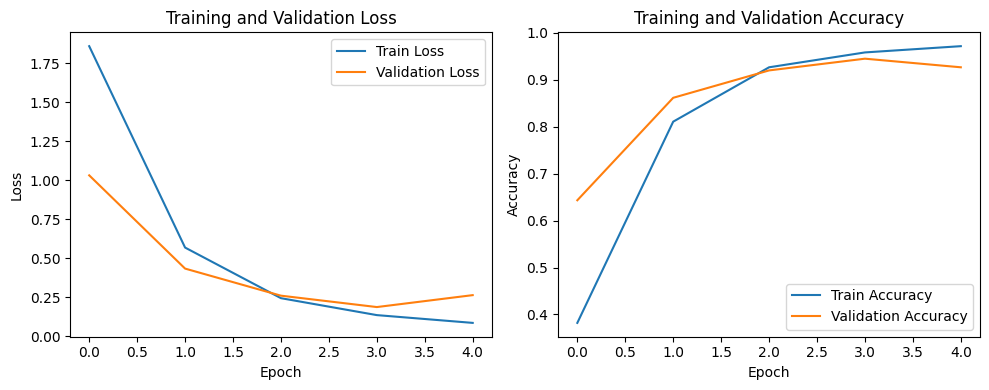

In [23]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

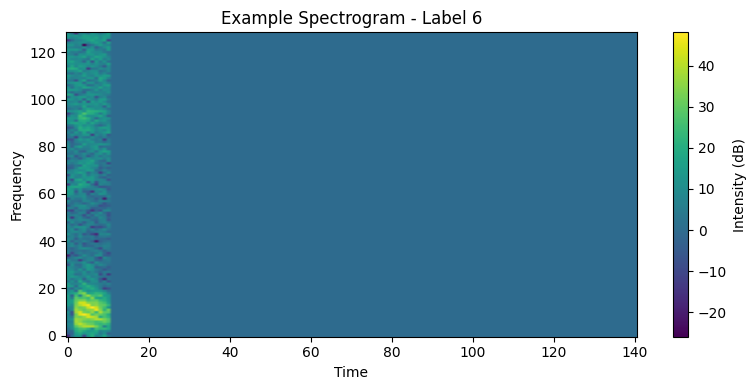

In [24]:
plt.figure(figsize=(8, 4))
plt.imshow(audio_df["spectrogram"].iloc[0], aspect="auto", origin="lower")
plt.title(f"Example Spectrogram - Label {audio_df['label'].iloc[0]}")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar(label="Intensity (dB)")
plt.tight_layout()
plt.show()